In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
zip_path = "/content/drive/MyDrive/GTSRBDataset/dataset.zip"
extract_path = '/content/GTSRB'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")

Dataset unzipped successfully!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ( Input,Conv2D,MaxPooling2D, Dense,Flatten, Dropout, BatchNormalization)

import seaborn as sns

In [ ]:
data = []
labels = []
classes = 43

# CORRECT PATH AFTER EXTRACTION
base_path = "/content/GTSRB"

for i in range(classes):

    path = os.path.join(base_path, 'train', str(i))  #Creates path to current class folder.

    images = os.listdir(path)

    for a in images:

        try:
            img_path = os.path.join(path, a)
            img = cv2.imread(img_path)

            img = cv2.resize(img, (30, 30))

            data.append(img)

            labels.append(i)

        except Exception as e:
            print("Error loading image:", a)
            print(e)

data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

Data Shape: (39209, 30, 30, 3)
Labels Shape: (39209,)


In [ ]:
#saving for future use
os.makedirs('training', exist_ok=True)# this prevent the folder is already exist
np.save('./training/data',data)
np.save('./training/target',labels)

In [ ]:
data = np.load('./training/data.npy')
data

array([[[[105, 107, 105],
         [102, 106, 104],
         [ 95, 109, 114],
         ...,
         [106, 139, 170],
         [132, 150, 164],
         [116, 130, 118]],

        [[103, 105, 103],
         [101, 106, 110],
         [108, 125, 137],
         ...,
         [101, 130, 173],
         [110, 135, 169],
         [114, 134, 151]],

        [[ 99, 103, 103],
         [107, 112, 124],
         [130, 133, 155],
         ...,
         [ 92, 126, 177],
         [ 93, 128, 171],
         [114, 131, 162]],

        ...,

        [[ 90,  91,  89],
         [ 87,  88,  88],
         [ 86,  86,  86],
         ...,
         [ 81,  81,  81],
         [ 79,  82,  82],
         [ 81,  83,  83]],

        [[ 87,  89,  87],
         [ 88,  89,  89],
         [ 86,  87,  87],
         ...,
         [ 81,  80,  79],
         [ 80,  82,  80],
         [ 82,  83,  83]],

        [[ 88,  88,  87],
         [ 88,  88,  88],
         [ 86,  87,  87],
         ...,
         [ 81,  80,  78],
        

In [ ]:
labels = np.load('./training/target.npy')
labels

array([ 0,  0,  0, ..., 42, 42, 42])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data,labels,test_size=0.2,random_state=42, stratify=labels
)

print("X_train:", X_train.shape)

print("X_test:",X_test.shape)

print("y_train:",y_train.shape)

print("y_test:", y_test.shape)

X_train: (31367, 30, 30, 3)
X_test: (7842, 30, 30, 3)
y_train: (31367,)
y_test: (7842,)


In [ ]:
#to_categorical converts data into onehot Encoder format
y_train = to_categorical(y_train,43)
y_test = to_categorical(y_test,43)
y_train,y_test

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]))

In [ ]:
#Build CNN model
model = Sequential()

model.add( Input(shape = X_train.shape[1:]))

model.add(Conv2D(32,(3,3), activation='relu'))

model.add( BatchNormalization())

model.add(Conv2D(32,(3,3),activation='relu'))

model.add( MaxPooling2D((2,2)))

model.add( Dropout(0.25))

In [ ]:
#Add second CNN block
model.add(Conv2D(64,(3,3),activation='relu'))

model.add( BatchNormalization())

model.add( Conv2D( 64,(3,3), activation='relu'))

model.add( MaxPooling2D((2,2)))

model.add( Dropout( 0.25))

In [ ]:
#Add Flatten + Dense layers
model.add( Flatten())

model.add(Dense(256,activation='relu'))

model.add(BatchNormalization())

model.add(Dropout(0.5))

model.add(Dense(43,activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,384,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,407,051 (5.37 MB)

 Trainable params: 1,406,475 (5.37 MB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
#Compile the model
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [ ]:
#Train the CNN model
history = model.fit( X_train,y_train,epochs=15,batch_size=32,validation_data=(X_test,  y_test))

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 111s 110ms/step - accuracy: 0.8328 - loss: 0.6527 - val_accuracy: 0.9722 - val_loss: 0.1057
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 102s 104ms/step - accuracy: 0.9653 - loss: 0.1305 - val_accuracy: 0.9844 - val_loss: 0.0583
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 102ms/step - accuracy: 0.9775 - loss: 0.0837 - val_accuracy: 0.9895 - val_loss: 0.0432
Epoch 4/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 104ms/step - accuracy: 0.9811 - loss: 0.0666 - val_accuracy: 0.9912 - val_loss: 0.0345
Epoch 5/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 141s 103ms/step - accuracy: 0.9824 - loss: 0.0620 - val_accuracy: 0.9936 - val_loss: 0.0275
Epoch 6/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 106s 108ms/step - accuracy: 0.9858 - loss: 0.0484 - val_accuracy: 0.9819 - val_loss: 0.0579
Epoch 7/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 100s 102ms/step - accuracy: 0.9872 - loss: 0.0432 - val_accuracy: 0.9931 - val_loss: 0.0249
Epoch 8/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 143s 103ms/step - accuracy: 0.9892 -

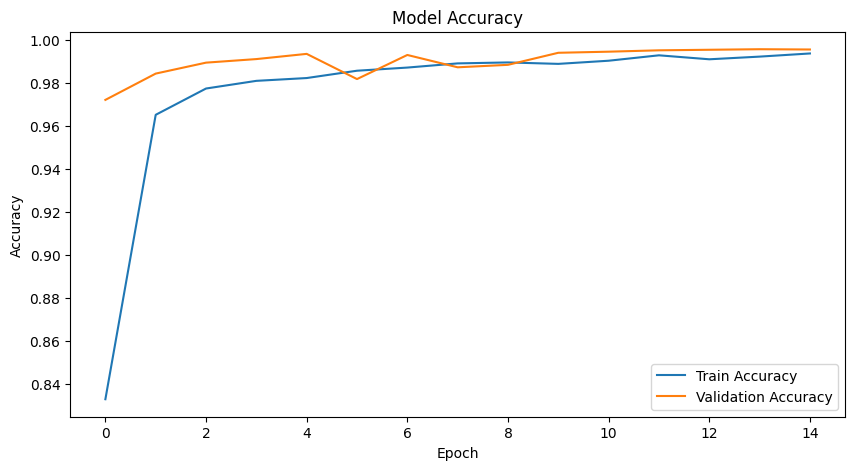

In [ ]:
# Accuracy graph
plt.figure(figsize=(10,5))
plt.plot( history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title( 'Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

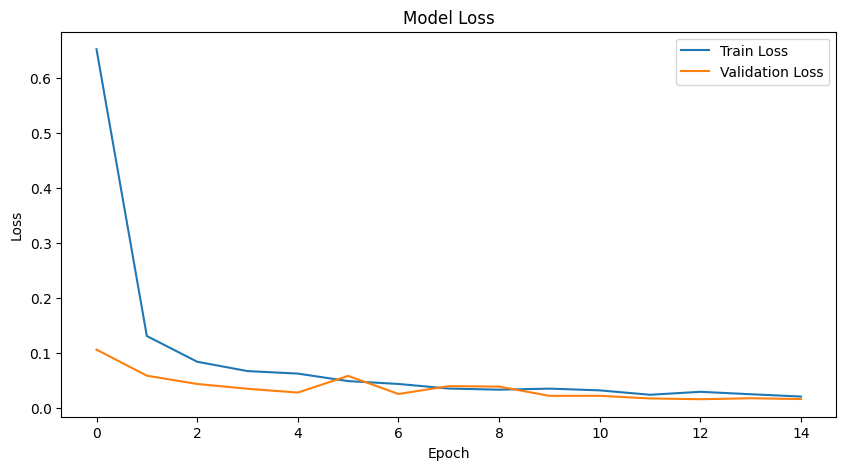

In [ ]:
# Loss graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
#final evaluation.
y_pred_prob = model.predict( X_test)
y_pred = np.argmax(y_pred_prob,axis=1)
y_true = np.argmax(y_test,axis=1)
print( y_pred)

246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step
[28  2  1 ...  3  2 12]


Accuracy: 0.9956643713338434
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       0.99      1.00      1.00       444
           2       1.00      0.99      0.99       450
           3       1.00      1.00      1.00       282
           4       1.00      0.99      1.00       396
           5       0.98      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       1.00      0.98      0.99       288
           8       0.99      0.99      0.99       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      0.99      0.99       264
          12       1.00      0.99      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      1.00      1.00       156
          15       0.98      1.00      0.99       126
          16       1.00      1.00      1.00        8

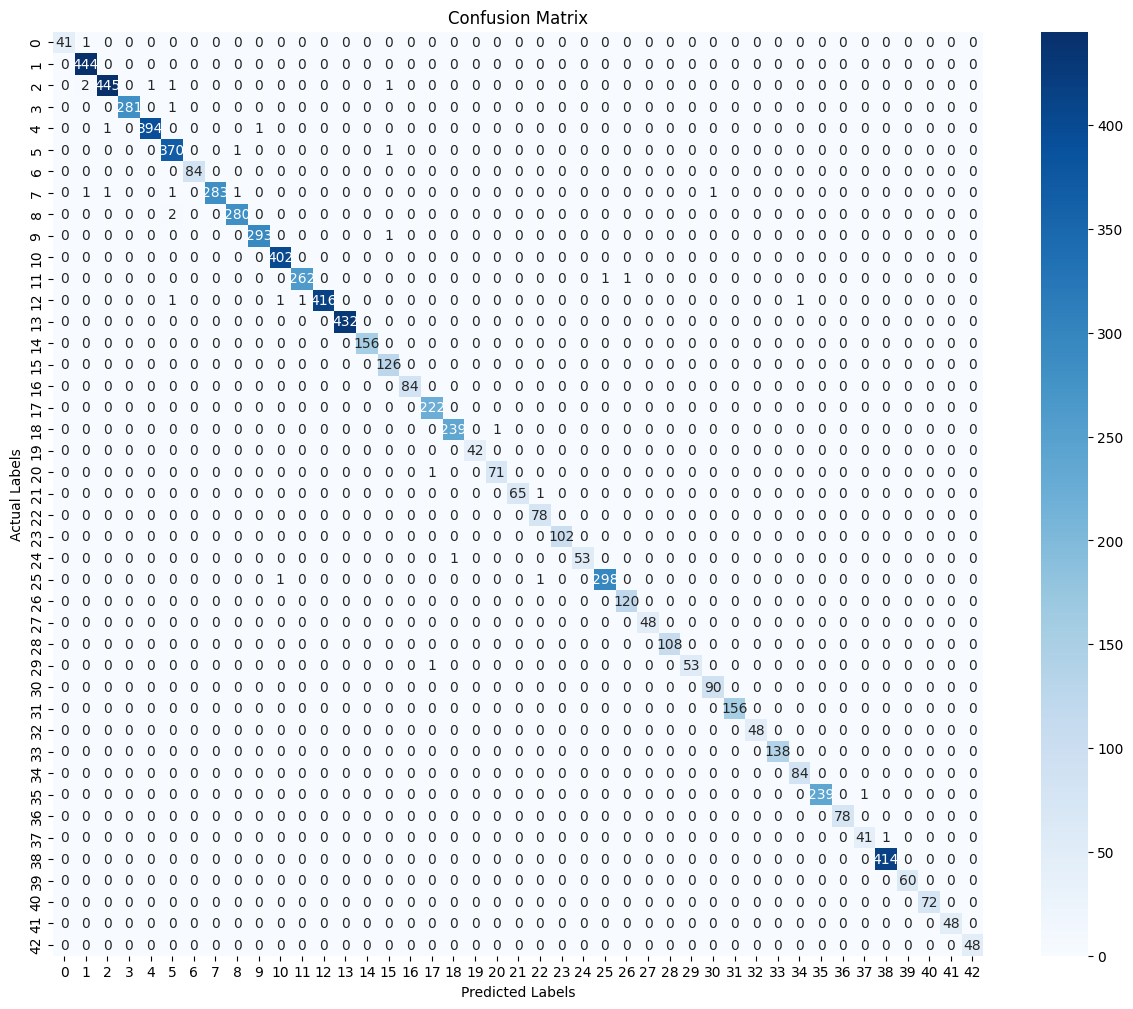

In [ ]:
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

import seaborn as sns
# Accuracy

acc = accuracy_score( y_true,y_pred)

print( "Accuracy:", acc)
# Classification report

print( classification_report( y_true, y_pred))
# Confusion matrix

cm = confusion_matrix( y_true,y_pred)
plt.figure(figsize=(15,12))
sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title(
    'Confusion Matrix'
)

plt.xlabel(
    'Predicted Labels'
)

plt.ylabel(
    'Actual Labels'
)

plt.show()